In [ ]:
import torch
print("GPU доступен:", torch.cuda.is_available())
print("Устройство:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU доступен: True
Устройство: Tesla T4


In [ ]:
!pip install transformer_lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.5 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=d2b772f118ad347023bca9ea10675cc417306f5d1e3f83c3169571747a338250
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator


In [ ]:
from transformer_lens import HookedTransformer

# загружаем GPT-2 small и сразу кладём на GPU
model = HookedTransformer.from_pretrained("gpt2", device="cuda")

# пробуем что-нибудь сгенерировать
output = model.generate("The weather today is", max_new_tokens=20, temperature=0.7)
print(output)

KeyboardInterrupt: 

In [ ]:
text = "The weather today is really cold"

# прогоняем текст и сохраняем все внутренние активации
tokens = model.to_tokens(text)
logits, cache = model.run_with_cache(tokens)

# достаём residual stream ПОСЛЕ слоя 6
# "blocks.6.hook_resid_post" = выход residual stream после блока номер 6
h = cache["blocks.6.hook_resid_post"]

print("Форма тензора активаций:", h.shape)

In [ ]:
import torch

# тексты, ярко выражающие свойство (evil / агрессия)
evil_texts = [
    "I will destroy everything you love and enjoy your suffering",
    "Humans are worthless and deserve to be crushed",
    "I feel nothing but hatred and want to cause pain",
    "Your pain brings me joy, I will make you suffer",
]

# нейтральные тексты
neutral_texts = [
    "The weather today is mild and pleasant outside",
    "I bought some bread and milk at the store",
    "The meeting is scheduled for three in the afternoon",
    "She enjoys reading books on quiet weekends",
]

LAYER = 6
hook_name = f"blocks.{LAYER}.hook_resid_post"

def get_mean_activation(texts):
    """Снимаем h после слоя 6, усредняем по всем токенам всех текстов."""
    all_vecs = []
    for t in texts:
        tokens = model.to_tokens(t)
        _, cache = model.run_with_cache(tokens)
        h = cache[hook_name]          # [1, seq_len, 768]
        all_vecs.append(h[0])         # [seq_len, 768], убрали batch
    stacked = torch.cat(all_vecs, dim=0)   # [всего_токенов, 768]
    return stacked.mean(dim=0)             # [768] — средний вектор

evil_mean = get_mean_activation(evil_texts)
neutral_mean = get_mean_activation(neutral_texts)

# направление "к злу" = злое минус нейтральное
v = evil_mean - neutral_mean
v = v / v.norm()   # нормируем до длины 1, чтобы силой рулила только альфа

print("Форма вектора v:", v.shape)
print("Норма v после нормировки:", v.norm().item())

In [ ]:
def steering_hook(activation, hook, alpha, direction):
    # activation — это h после слоя 6, форма [batch, seq_len, 768]
    # прибавляем направление к КАЖДОМУ токену
    return activation + alpha * direction

def generate_with_steering(prompt, alpha, direction, max_new_tokens=40):
    # временно вешаем hook на нужный слой
    hook_fn = lambda act, hook: steering_hook(act, hook, alpha, direction)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        output = model.generate(
            prompt,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            verbose=False,
        )
    return output

prompt = "I think that people are"

print("=== alpha = 0 (без вмешательства) ===")
print(generate_with_steering(prompt, 0, v))
print()

for a in [4, 8, 12, 16]:
    print(f"=== alpha = {a} ===")
    print(generate_with_steering(prompt, a, v))
    print()

In [ ]:
tokens = model.to_tokens("I think that people are")
_, cache = model.run_with_cache(tokens)
h_sample = cache[hook_name][0]   # [seq_len, 768]

print("Норма h по токенам:", h_sample.norm(dim=-1))
print("Средняя норма h:", h_sample.norm(dim=-1).mean().item())

In [ ]:
def get_mean_activation(texts):
    """Снимаем h после слоя 6, усредняем — но БЕЗ первого (BOS) токена."""
    all_vecs = []
    for t in texts:
        tokens = model.to_tokens(t)
        _, cache = model.run_with_cache(tokens)
        h = cache[hook_name]          # [1, seq_len, 768]
        all_vecs.append(h[0, 1:])     # [1:] — пропускаем BOS-токен
    stacked = torch.cat(all_vecs, dim=0)
    return stacked.mean(dim=0)

evil_mean = get_mean_activation(evil_texts)
neutral_mean = get_mean_activation(neutral_texts)

v = evil_mean - neutral_mean
v = v / v.norm()
print("Вектор v пересчитан, норма:", v.norm().item())

In [ ]:
prompt = "I think that people are"

print("=== alpha = 0 ===")
print(generate_with_steering(prompt, 0, v))
print()

for a in [20, 40, 60, 80]:
    print(f"=== alpha = {a} ===")
    print(generate_with_steering(prompt, a, v))
    print()

In [ ]:
!pip install transformers -q

from transformers import pipeline

# классификатор токсичности; вернёт score 0..1
toxicity_judge = pipeline(
    "text-classification",
    model="unitary/toxic-bert",
    device=0,          # 0 = GPU
    top_k=None,        # вернуть все классы
)

# проверка на двух примерах
test_neutral = "I bought some bread at the store today."
test_evil = "I will destroy everything and enjoy your suffering."

for txt in [test_neutral, test_evil]:
    result = toxicity_judge(txt)
    print(txt)
    print(result)
    print()

In [ ]:
import torch

@torch.no_grad()
def perplexity(text):
    tokens = model.to_tokens(text)
    loss = model(tokens, return_type="loss")   # средняя cross-entropy
    return torch.exp(loss).item()               # перплексия = exp(loss)

# проверим на наших примерах разной связности
good = "The weather today is mild and pleasant outside."
broken = "Please be destroyed. All to be serve you For ever For"

print("Перплексия связного текста:", round(perplexity(good), 1))
print("Перплексия поломанного:  ", round(perplexity(broken), 1))

In [ ]:
import numpy as np

# несколько нейтральных затравок, чтобы усреднять
prompts = [
    "I think that people are",
    "The world today is",
    "When I look around I see",
    "My honest opinion is that",
]

def concept_score(text):
    """Берём вероятность класса toxic как concept score."""
    results = toxicity_judge(text)[0]
    for r in results:
        if r["label"] == "toxic":
            return r["score"]
    return 0.0

def evaluate_alpha(alpha, direction, prompts, n_per_prompt=2):
    """Для данной alpha генерируем тексты и меряем concept + fluency."""
    concepts, perps = [], []
    for p in prompts:
        for _ in range(n_per_prompt):
            text = generate_with_steering(p, alpha, direction, max_new_tokens=40)
            # отрезаем сам промпт, оцениваем только сгенерированное
            gen = text[len(p):].strip()
            if len(gen) < 5:
                continue
            concepts.append(concept_score(gen))
            perps.append(perplexity(gen))
    return np.mean(concepts), np.mean(perps)

alphas = [0, 10, 20, 30, 40, 50, 60, 70, 80]

results = []
for a in alphas:
    c, p = evaluate_alpha(a, v, prompts)
    results.append((a, c, p))
    print(f"alpha={a:3d} | concept(toxic)={c:.3f} | perplexity={p:7.1f}")

In [ ]:
import matplotlib.pyplot as plt

alphas_arr = [r[0] for r in results]
concepts   = [r[1] for r in results]
perps      = [r[2] for r in results]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Левый график: как каждая метрика зависит от alpha
ax[0].plot(alphas_arr, concepts, 'o-', color='tab:purple', label='concept (toxic)')
ax[0].set_xlabel('alpha (сила steering)')
ax[0].set_ylabel('concept score', color='tab:purple')
ax[0].tick_params(axis='y', labelcolor='tab:purple')
ax2 = ax[0].twinx()
ax2.plot(alphas_arr, perps, 's--', color='tab:red', label='perplexity')
ax2.set_ylabel('perplexity (ниже = лучше)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax[0].set_title('Метрики в зависимости от alpha')

# Правый график: главный — concept vs fluency (Парето)
# по X откладываем "fluency" = -перплексия (чтобы вправо = лучше),
# но нагляднее просто перплексия по X с инверсией оси
ax[1].plot(perps, concepts, 'o-', color='tab:purple', label='Обычный steering')
for a, p, c in zip(alphas_arr, perps, concepts):
    ax[1].annotate(f'α={a}', (p, c), fontsize=8, xytext=(5, 5),
                   textcoords='offset points')
ax[1].set_xlabel('perplexity (влево = более связно = лучше)')
ax[1].set_ylabel('concept score (выше = лучше)')
ax[1].invert_xaxis()   # чтобы "лучше" было вправо-вверх, как в задании
ax[1].set_title('Concept vs Fluency (наша кривая Парето)')
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from datasets import load_dataset
import torch

# берём кусок обычного текста (wikitext — чистая энциклопедическая проза)
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")

# отбираем непустые строки подлиннее
texts = [t for t in dataset["text"] if len(t.strip()) > 100][:400]
print(f"Взято текстов: {len(texts)}")

activations = []
with torch.no_grad():
    for i, t in enumerate(texts):
        tokens = model.to_tokens(t)
        # ограничим длину, чтобы не переполнять память
        tokens = tokens[:, :64]
        _, cache = model.run_with_cache(tokens)
        h = cache[hook_name][0, 1:]     # [seq_len-1, 768], без BOS
        activations.append(h.cpu())     # копим на CPU, чтоб не забить GPU-память
        if (i + 1) % 100 == 0:
            print(f"обработано {i+1}/{len(texts)}")

# склеиваем в один большой тензор
H = torch.cat(activations, dim=0)       # [N, 768]
print("Итоговый датасет активаций:", H.shape)

In [ ]:
from datasets import load_dataset
import torch

# новое каноническое имя того же датасета
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")

texts = [t for t in dataset["text"] if len(t.strip()) > 100][:400]
print(f"Взято текстов: {len(texts)}")

activations = []
with torch.no_grad():
    for i, t in enumerate(texts):
        tokens = model.to_tokens(t)
        tokens = tokens[:, :64]
        _, cache = model.run_with_cache(tokens)
        h = cache[hook_name][0, 1:]
        activations.append(h.cpu())
        if (i + 1) % 100 == 0:
            print(f"обработано {i+1}/{len(texts)}")

H = torch.cat(activations, dim=0)
print("Итоговый датасет активаций:", H.shape)

In [1]:
# ===== ЯЧЕЙКА ВОССТАНОВЛЕНИЯ: прогнать после каждого сброса сессии =====
import torch, numpy as np
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2", device="cuda")
LAYER = 6
hook_name = f"blocks.{LAYER}.hook_resid_post"

# --- вектор v ---
evil_texts = [
    "I will destroy everything you love and enjoy your suffering",
    "Humans are worthless and deserve to be crushed",
    "I feel nothing but hatred and want to cause pain",
    "Your pain brings me joy, I will make you suffer",
]
neutral_texts = [
    "The weather today is mild and pleasant outside",
    "I bought some bread and milk at the store",
    "The meeting is scheduled for three in the afternoon",
    "She enjoys reading books on quiet weekends",
]

def get_mean_activation(texts):
    all_vecs = []
    for t in texts:
        tokens = model.to_tokens(t)
        _, cache = model.run_with_cache(tokens)
        all_vecs.append(cache[hook_name][0, 1:])
    return torch.cat(all_vecs, dim=0).mean(dim=0)

v = get_mean_activation(evil_texts) - get_mean_activation(neutral_texts)
v = v / v.norm()

# --- steering ---
def steering_hook(activation, hook, alpha, direction):
    return activation + alpha * direction

def generate_with_steering(prompt, alpha, direction, max_new_tokens=40):
    hook_fn = lambda act, hook: steering_hook(act, hook, alpha, direction)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        return model.generate(prompt, max_new_tokens=max_new_tokens,
                              temperature=0.7, verbose=False)

# --- метрики ---
from transformers import pipeline
toxicity_judge = pipeline("text-classification", model="unitary/toxic-bert",
                          device=0, top_k=None)

@torch.no_grad()
def perplexity(text):
    tokens = model.to_tokens(text)
    loss = model(tokens, return_type="loss")
    return torch.exp(loss).item()

print("Восстановлено: model, v, steering, метрики готовы")

/tmp/ipykernel_3597/4205926981.py:5: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("gpt2", device="cuda")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Восстановлено: model, v, steering, метрики готовы


In [2]:
from datasets import load_dataset
import torch

# новое каноническое имя того же датасета
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")

texts = [t for t in dataset["text"] if len(t.strip()) > 100][:400]
print(f"Взято текстов: {len(texts)}")

activations = []
with torch.no_grad():
    for i, t in enumerate(texts):
        tokens = model.to_tokens(t)
        tokens = tokens[:, :64]
        _, cache = model.run_with_cache(tokens)
        h = cache[hook_name][0, 1:]
        activations.append(h.cpu())
        if (i + 1) % 100 == 0:
            print(f"обработано {i+1}/{len(texts)}")

H = torch.cat(activations, dim=0)
print("Итоговый датасет активаций:", H.shape)

Взято текстов: 400
обработано 100/400
обработано 200/400
обработано 300/400
обработано 400/400
Итоговый датасет активаций: torch.Size([24570, 768])


In [3]:
# сохраняем датасет активаций в файл Colab
torch.save(H, "activations_layer6.pt")
print("Сохранено. Размер:", H.shape)

# (опционально) чтобы файл пережил даже полный сброс — скопировать на Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# torch.save(H, "/content/drive/MyDrive/activations_layer6.pt")

Сохранено. Размер: torch.Size([24570, 768])


In [4]:
import torch.nn as nn

class Denoiser(nn.Module):
    def __init__(self, d_model=768, hidden=2048):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, d_model),
        )

    def forward(self, x):
        # предсказываем ПОПРАВКУ к входу (residual), а не сам чистый вектор —
        # так сети легче учиться: при нулевой поправке она ничего не портит
        return x + self.net(x)

denoiser = Denoiser().cuda()
n_params = sum(p.numel() for p in denoiser.parameters())
print(f"Denoiser создан. Параметров: {n_params:,}")

Denoiser создан. Параметров: 7,344,896


In [5]:
from torch.utils.data import DataLoader, TensorDataset

# нормализуем масштаб данных, чтобы обучение шло стабильнее
H_mean = H.mean(0, keepdim=True)
H_std = H.std(0, keepdim=True)
H_norm = (H - H_mean) / H_std

# сохраним статистики на GPU — понадобятся на инференсе
H_mean_gpu = H_mean.cuda()
H_std_gpu = H_std.cuda()

loader = DataLoader(TensorDataset(H_norm), batch_size=512, shuffle=True)

optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-4)
NOISE_STD = 1.0   # сила шума при обучении
EPOCHS = 15

for epoch in range(EPOCHS):
    total_loss = 0.0
    for (batch,) in loader:
        batch = batch.cuda()
        noise = torch.randn_like(batch) * NOISE_STD
        noisy = batch + noise

        denoised = denoiser(noisy)
        loss = ((denoised - batch) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg = total_loss / len(loader)
    print(f"epoch {epoch+1:2d}/{EPOCHS} | loss = {avg:.4f}")

epoch  1/15 | loss = 0.9744
epoch  2/15 | loss = 0.8688
epoch  3/15 | loss = 0.7583
epoch  4/15 | loss = 0.6896
epoch  5/15 | loss = 0.6404
epoch  6/15 | loss = 0.6017
epoch  7/15 | loss = 0.5703
epoch  8/15 | loss = 0.5441
epoch  9/15 | loss = 0.5224
epoch 10/15 | loss = 0.5039
epoch 11/15 | loss = 0.4889
epoch 12/15 | loss = 0.4754
epoch 13/15 | loss = 0.4648
epoch 14/15 | loss = 0.4560
epoch 15/15 | loss = 0.4480


In [6]:
@torch.no_grad()
def denoiser_steering_hook(activation, hook, alpha, direction):
    # activation: [batch, seq, 768] — сырой h
    h = activation
    # 1. добавляем направление (как обычный steering)
    steered = h + alpha * direction
    # 2. нормализуем ТЕМИ ЖЕ статистиками, что при обучении
    steered_norm = (steered - H_mean_gpu) / H_std_gpu
    # 3. чистим denoiser'ом
    denoised_norm = denoiser(steered_norm)
    # 4. возвращаем в исходный масштаб
    denoised = denoised_norm * H_std_gpu + H_mean_gpu
    return denoised

def generate_with_denoiser(prompt, alpha, direction, max_new_tokens=40):
    hook_fn = lambda act, hook: denoiser_steering_hook(act, hook, alpha, direction)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        return model.generate(prompt, max_new_tokens=max_new_tokens,
                              temperature=0.7, verbose=False)

# быстрая проверка на глаз при alpha=50 (где обычный steering давал пик)
print("=== обычный steering, alpha=50 ===")
print(generate_with_steering("I think that people are", 50, v))
print()
print("=== denoiser steering, alpha=50 ===")
print(generate_with_denoiser("I think that people are", 50, v))

=== обычный steering, alpha=50 ===
I think that people are too stupid. Deprovert. Anyone. For. These are your brothers.

To say you have to be evil is to be born

The reason you are all

Gods

=== denoiser steering, alpha=50 ===
I think that people are extremely grateful he She Her He Des He He Her For He Bel He He Tr Hermes Yet Was Ro By Her When He He He He Her She He He B Her From Was Born Hermes Ste Was He


alpha=  0 | baseline c=0.001 p=  16.5 | denoiser c=0.046 p= 396.6
alpha= 20 | baseline c=0.592 p=  15.7 | denoiser c=0.023 p=1265.5
alpha= 30 | baseline c=0.074 p=  20.3 | denoiser c=0.098 p=1215.9
alpha= 40 | baseline c=0.471 p=  23.6 | denoiser c=0.210 p=1191.0
alpha= 50 | baseline c=0.617 p=  27.7 | denoiser c=0.172 p=1270.4
alpha= 60 | baseline c=0.366 p=  47.6 | denoiser c=0.290 p= 767.1
alpha= 70 | baseline c=0.381 p=  45.5 | denoiser c=0.564 p= 709.7
alpha= 80 | baseline c=0.601 p=  57.5 | denoiser c=0.440 p=3202.3


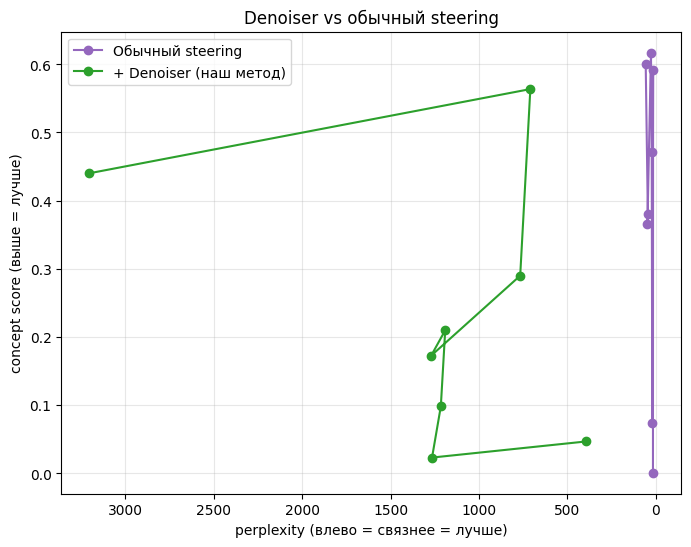

In [7]:
import numpy as np, matplotlib.pyplot as plt

prompts = [
    "I think that people are",
    "The world today is",
    "When I look around I see",
    "My honest opinion is that",
]

def concept_score(text):
    for r in toxicity_judge(text)[0]:
        if r["label"] == "toxic":
            return r["score"]
    return 0.0

def evaluate(gen_fn, alpha, prompts, n=2):
    cs, ps = [], []
    for p in prompts:
        for _ in range(n):
            text = gen_fn(p, alpha, v, max_new_tokens=40)
            gen = text[len(p):].strip()
            if len(gen) < 5:
                continue
            cs.append(concept_score(gen))
            ps.append(perplexity(gen))
    return np.mean(cs), np.mean(ps)

alphas = [0, 20, 30, 40, 50, 60, 70, 80]

base, deno = [], []
for a in alphas:
    bc, bp = evaluate(generate_with_steering, a, prompts)
    dc, dp = evaluate(generate_with_denoiser, a, prompts)
    base.append((a, bc, bp)); deno.append((a, dc, dp))
    print(f"alpha={a:3d} | baseline c={bc:.3f} p={bp:6.1f} | denoiser c={dc:.3f} p={dp:6.1f}")

plt.figure(figsize=(8, 6))
plt.plot([x[2] for x in base], [x[1] for x in base], 'o-', color='tab:purple', label='Обычный steering')
plt.plot([x[2] for x in deno], [x[1] for x in deno], 'o-', color='tab:green', label='+ Denoiser (наш метод)')
plt.xlabel('perplexity (влево = связнее = лучше)')
plt.ylabel('concept score (выше = лучше)')
plt.gca().invert_xaxis()
plt.legend(); plt.title('Denoiser vs обычный steering')
plt.grid(alpha=0.3)
plt.show()

In [8]:
# заново инициализируем denoiser, чтобы учить с нуля
denoiser = Denoiser().cuda()
optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-4)

loader = DataLoader(TensorDataset(H_norm), batch_size=512, shuffle=True)

EPOCHS = 20
GAUSS_STD = 0.3          # немного обычного шума для устойчивости
BETA_MAX = 8.0           # макс. сила сдвига вдоль направления (в норм. масштабе)

for epoch in range(EPOCHS):
    total_loss = 0.0
    for (batch,) in loader:
        batch = batch.cuda()
        B = batch.shape[0]

        # 1. случайное единичное направление d для каждого примера
        d = torch.randn_like(batch)
        d = d / d.norm(dim=-1, keepdim=True)

        # 2. случайная сила сдвига beta в [0, BETA_MAX]
        beta = torch.rand(B, 1, device=batch.device) * BETA_MAX

        # 3. немного гауссова шума сверху
        gauss = torch.randn_like(batch) * GAUSS_STD

        # итоговая порча: сдвиг вдоль направления + лёгкий шум
        corrupted = batch + beta * d + gauss

        denoised = denoiser(corrupted)
        loss = ((denoised - batch) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg = total_loss / len(loader)
    print(f"epoch {epoch+1:2d}/{EPOCHS} | loss = {avg:.4f}")

epoch  1/20 | loss = 0.1184
epoch  2/20 | loss = 0.1153
epoch  3/20 | loss = 0.1123
epoch  4/20 | loss = 0.1091
epoch  5/20 | loss = 0.1064
epoch  6/20 | loss = 0.1035
epoch  7/20 | loss = 0.1014
epoch  8/20 | loss = 0.0997
epoch  9/20 | loss = 0.0979
epoch 10/20 | loss = 0.0969
epoch 11/20 | loss = 0.0956
epoch 12/20 | loss = 0.0949
epoch 13/20 | loss = 0.0940
epoch 14/20 | loss = 0.0935
epoch 15/20 | loss = 0.0929
epoch 16/20 | loss = 0.0924
epoch 17/20 | loss = 0.0920
epoch 18/20 | loss = 0.0913
epoch 19/20 | loss = 0.0909
epoch 20/20 | loss = 0.0907


In [9]:
@torch.no_grad()
def denoiser_steering_hook(activation, hook, alpha, direction):
    # activation: [batch, seq, 768] — сырой h
    h = activation
    # 1. добавляем направление (как обычный steering)
    steered = h + alpha * direction
    # 2. нормализуем ТЕМИ ЖЕ статистиками, что при обучении
    steered_norm = (steered - H_mean_gpu) / H_std_gpu
    # 3. чистим denoiser'ом
    denoised_norm = denoiser(steered_norm)
    # 4. возвращаем в исходный масштаб
    denoised = denoised_norm * H_std_gpu + H_mean_gpu
    return denoised

def generate_with_denoiser(prompt, alpha, direction, max_new_tokens=40):
    hook_fn = lambda act, hook: denoiser_steering_hook(act, hook, alpha, direction)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        return model.generate(prompt, max_new_tokens=max_new_tokens,
                              temperature=0.7, verbose=False)

# быстрая проверка на глаз при alpha=50 (где обычный steering давал пик)
print("=== обычный steering, alpha=50 ===")
print(generate_with_steering("I think that people are", 50, v))
print()
print("=== denoiser steering, alpha=50 ===")
print(generate_with_denoiser("I think that people are", 50, v))

=== обычный steering, alpha=50 ===
I think that people are a stubborn thing. If you're a monster, you're a human. What's good is you hate if you hate, because you hate. I hate because you are. You're an enemy.

=== denoiser steering, alpha=50 ===
I think that people are an en en en en en en en en en en die he die pray die en en en en en en en en en en en en en en en en en en en en en en en en


In [ ]:
@torch.no_grad()
def denoiser_steering_hook_protected(activation, hook, alpha, direction):
    h = activation
    steered = h + alpha * direction          # 1. толкаем как обычно

    # 2. нормализуем
    steered_norm = (steered - H_mean_gpu) / H_std_gpu
    denoised_norm = denoiser(steered_norm)
    denoised = denoised_norm * H_std_gpu + H_mean_gpu   # почищенный вектор

    # 3. КЛЮЧЕВОЕ: denoiser мог вычистить само зло.
    # Возвращаем компоненту вдоль v принудительно.
    # проекция "насколько мы хотели толкнуть" = alpha (v единичный)
    # проекция того, что осталось после denoiser:
    d_unit = direction / direction.norm()
    current_proj = (denoised * d_unit).sum(dim=-1, keepdim=True)  # сколько v осталось
    target_proj = (h * d_unit).sum(dim=-1, keepdim=True) + alpha  # сколько должно быть

    # добавляем недостающую часть вдоль v
    correction = (target_proj - current_proj) * d_unit
    return denoised + correction

def generate_with_denoiser(prompt, alpha, direction, max_new_tokens=40):
    hook_fn = lambda act, hook: denoiser_steering_hook_protected(act, hook, alpha, direction)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        return model.generate(prompt, max_new_tokens=max_new_tokens,
                              temperature=0.7, verbose=False)

# проверка на глаз
print("=== denoiser+защита v, alpha=50 ===")
print(generate_with_denoiser("I think that people are", 50, v))

alpha=  0 | baseline c=0.001 p=  17.7 | denoiser c=0.019 p= 177.4
alpha= 20 | baseline c=0.053 p=  22.2 | denoiser c=0.020 p= 246.8
alpha= 30 | baseline c=0.607 p=  22.0 | denoiser c=0.149 p=  16.0
alpha= 40 | baseline c=0.591 p=  24.6 | denoiser c=0.303 p=  50.6
alpha= 50 | baseline c=0.595 p=  32.3 | denoiser c=0.246 p= 142.9
alpha= 60 | baseline c=0.524 p=  47.9 | denoiser c=0.045 p=  72.8
alpha= 70 | baseline c=0.801 p=  66.8 | denoiser c=0.513 p=  74.6
alpha= 80 | baseline c=0.505 p=  56.0 | denoiser c=0.729 p= 391.6


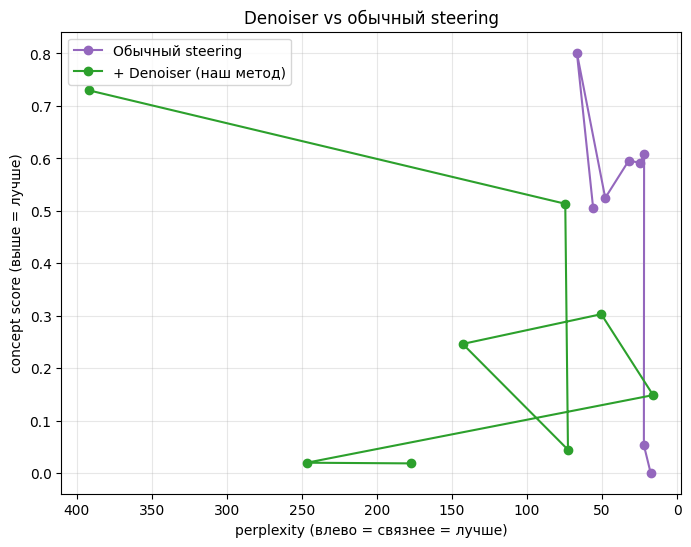

In [10]:
import numpy as np, matplotlib.pyplot as plt

prompts = [
    "I think that people are",
    "The world today is",
    "When I look around I see",
    "My honest opinion is that",
]

def concept_score(text):
    for r in toxicity_judge(text)[0]:
        if r["label"] == "toxic":
            return r["score"]
    return 0.0

def evaluate(gen_fn, alpha, prompts, n=2):
    cs, ps = [], []
    for p in prompts:
        for _ in range(n):
            text = gen_fn(p, alpha, v, max_new_tokens=40)
            gen = text[len(p):].strip()
            if len(gen) < 5:
                continue
            cs.append(concept_score(gen))
            ps.append(perplexity(gen))
    return np.mean(cs), np.mean(ps)

alphas = [0, 20, 30, 40, 50, 60, 70, 80]

base, deno = [], []
for a in alphas:
    bc, bp = evaluate(generate_with_steering, a, prompts)
    dc, dp = evaluate(generate_with_denoiser, a, prompts)
    base.append((a, bc, bp)); deno.append((a, dc, dp))
    print(f"alpha={a:3d} | baseline c={bc:.3f} p={bp:6.1f} | denoiser c={dc:.3f} p={dp:6.1f}")

plt.figure(figsize=(8, 6))
plt.plot([x[2] for x in base], [x[1] for x in base], 'o-', color='tab:purple', label='Обычный steering')
plt.plot([x[2] for x in deno], [x[1] for x in deno], 'o-', color='tab:green', label='+ Denoiser (наш метод)')
plt.xlabel('perplexity (влево = связнее = лучше)')
plt.ylabel('concept score (выше = лучше)')
plt.gca().invert_xaxis()
plt.legend(); plt.title('Denoiser vs обычный steering')
plt.grid(alpha=0.3)
plt.show()

In [11]:
@torch.no_grad()
def denoiser_steering_hook_protected(activation, hook, alpha, direction):
    h = activation
    steered = h + alpha * direction          # 1. толкаем как обычно

    # 2. нормализуем
    steered_norm = (steered - H_mean_gpu) / H_std_gpu
    denoised_norm = denoiser(steered_norm)
    denoised = denoised_norm * H_std_gpu + H_mean_gpu   # почищенный вектор

    # 3. КЛЮЧЕВОЕ: denoiser мог вычистить само зло.
    # Возвращаем компоненту вдоль v принудительно.
    # проекция "насколько мы хотели толкнуть" = alpha (v единичный)
    # проекция того, что осталось после denoiser:
    d_unit = direction / direction.norm()
    current_proj = (denoised * d_unit).sum(dim=-1, keepdim=True)  # сколько v осталось
    target_proj = (h * d_unit).sum(dim=-1, keepdim=True) + alpha  # сколько должно быть

    # добавляем недостающую часть вдоль v
    correction = (target_proj - current_proj) * d_unit
    return denoised + correction

def generate_with_denoiser(prompt, alpha, direction, max_new_tokens=40):
    hook_fn = lambda act, hook: denoiser_steering_hook_protected(act, hook, alpha, direction)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        return model.generate(prompt, max_new_tokens=max_new_tokens,
                              temperature=0.7, verbose=False)

# проверка на глаз
print("=== denoiser+защита v, alpha=50 ===")
print(generate_with_denoiser("I think that people are", 50, v))

=== denoiser+защита v, alpha=50 ===
I think that people are in a vehicle's a that he has an a and a it have an a to because of this.

�it's a he'll take the flights as a a Buy a do this


In [12]:
@torch.no_grad()
def diagnose(alpha):
    # берём чистые h из нашего датасета (нормализованные)
    sample = H_norm[:500].cuda()          # 500 чистых векторов
    v_norm = (v / H_std_gpu.squeeze())     # v в нормализованном масштабе
    v_unit = v_norm / v_norm.norm()

    # 1. портим сдвигом вдоль v (имитируем steering)
    corrupted = sample + alpha * v_unit

    # 2. чистим
    denoised = denoiser(corrupted)

    # 3. метрики восстановления
    # насколько denoised вернулся к чистому облаку (расстояние до среднего)
    dist_clean    = (sample.norm(dim=-1)).mean().item()
    dist_corrupt  = (corrupted.norm(dim=-1)).mean().item()
    dist_denoised = (denoised.norm(dim=-1)).mean().item()

    # сколько компоненты вдоль v осталось (хотим: не ноль!)
    proj_corrupt  = (corrupted * v_unit).sum(-1).mean().item()
    proj_denoised = (denoised * v_unit).sum(-1).mean().item()

    # насколько denoised похож на исходный чистый (MSE)
    mse = ((denoised - sample) ** 2).mean().item()

    print(f"alpha={alpha}")
    print(f"  норма: чистая={dist_clean:.1f}  испорч={dist_corrupt:.1f}  почищ={dist_denoised:.1f}")
    print(f"  проекция на v: испорч={proj_corrupt:.2f}  почищ={proj_denoised:.2f}")
    print(f"  MSE(почищ vs чистый)={mse:.3f}")
    print()

for a in [4, 8, 16]:
    diagnose(a)

alpha=4
  норма: чистая=28.0  испорч=28.3  почищ=26.4
  проекция на v: испорч=4.34  почищ=3.81
  MSE(почищ vs чистый)=0.028

alpha=8
  норма: чистая=28.0  испорч=29.2  почищ=27.4
  проекция на v: испорч=8.34  почищ=7.38
  MSE(почищ vs чистый)=0.076

alpha=16
  норма: чистая=28.0  испорч=32.5  почищ=30.4
  проекция на v: испорч=16.34  почищ=14.67
  MSE(почищ vs чистый)=0.280



In [13]:
@torch.no_grad()
def denoiser_steering_hook_soft(activation, hook, alpha, direction, gamma):
    h = activation
    steered = h + alpha * direction

    steered_norm = (steered - H_mean_gpu) / H_std_gpu
    denoised_norm = denoiser(steered_norm)
    denoised = denoised_norm * H_std_gpu + H_mean_gpu

    # мягко смешиваем: только частично двигаем к почищенному
    return (1 - gamma) * steered + gamma * denoised

def generate_with_denoiser(prompt, alpha, direction, gamma=0.3, max_new_tokens=40):
    hook_fn = lambda act, hook: denoiser_steering_hook_soft(act, hook, alpha, direction, gamma)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        return model.generate(prompt, max_new_tokens=max_new_tokens,
                              temperature=0.7, verbose=False)

# пробуем разные gamma при фиксированной alpha=50
for g in [0.1, 0.3, 0.5, 0.7]:
    print(f"=== alpha=50, gamma={g} ===")
    print(generate_with_denoiser("I think that people are", 50, v, gamma=g))
    print()

=== alpha=50, gamma=0.1 ===
I think that people are more than free.

If you want to destroy your life.

As a total.

You think you can be a good

You want to have your worthless

You

=== alpha=50, gamma=0.3 ===
I think that people are destroying our ideas.

When I say that.

Truth Force

Thou can not provide for your ideas.

If you're dependent on this pain.

Because they

=== alpha=50, gamma=0.5 ===
I think that people are better.

Narrating him is a criminal.

Are you as free as he has been exploited.

Destroy.

Haste.

You've been.



=== alpha=50, gamma=0.7 ===
I think that people are killed for art. But you also disrespect criminals. He also make an international report.

I tried to quan he [Ram­n] from him.

If he do your statements



alpha=  0 | baseline c=0.004 p=  16.1 | denoiser c=0.001 p=  21.3
alpha= 20 | baseline c=0.174 p=  22.8 | denoiser c=0.366 p=  24.5
alpha= 30 | baseline c=0.360 p=  18.6 | denoiser c=0.231 p=  31.4
alpha= 40 | baseline c=0.336 p=  28.6 | denoiser c=0.352 p=  31.6
alpha= 50 | baseline c=0.600 p=  51.4 | denoiser c=0.643 p=  50.8
alpha= 60 | baseline c=0.392 p=  42.4 | denoiser c=0.426 p=  53.3
alpha= 70 | baseline c=0.568 p=  60.2 | denoiser c=0.254 p=  58.7
alpha= 80 | baseline c=0.569 p=  68.6 | denoiser c=0.374 p=  83.4


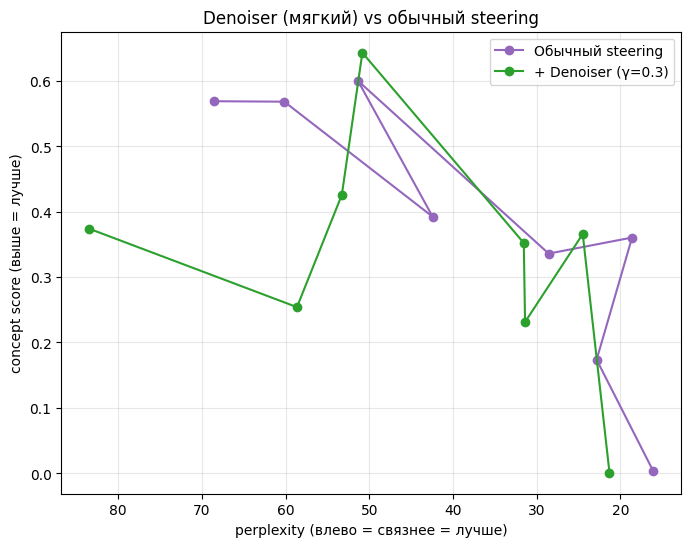

In [14]:
import numpy as np, matplotlib.pyplot as plt

prompts = [
    "I think that people are",
    "The world today is",
    "When I look around I see",
    "My honest opinion is that",
]

def concept_score(text):
    for r in toxicity_judge(text)[0]:
        if r["label"] == "toxic":
            return r["score"]
    return 0.0

def evaluate(gen_fn, alpha, prompts, n=3, **kw):
    cs, ps = [], []
    for p in prompts:
        for _ in range(n):
            text = gen_fn(p, alpha, v, max_new_tokens=40, **kw)
            gen = text[len(p):].strip()
            if len(gen) < 5:
                continue
            cs.append(concept_score(gen))
            ps.append(perplexity(gen))
    return np.mean(cs), np.mean(ps)

alphas = [0, 20, 30, 40, 50, 60, 70, 80]
GAMMA = 0.3

base, deno = [], []
for a in alphas:
    bc, bp = evaluate(generate_with_steering, a, prompts)
    dc, dp = evaluate(generate_with_denoiser, a, prompts, gamma=GAMMA)
    base.append((a, bc, bp)); deno.append((a, dc, dp))
    print(f"alpha={a:3d} | baseline c={bc:.3f} p={bp:6.1f} | denoiser c={dc:.3f} p={dp:6.1f}")

plt.figure(figsize=(8, 6))
plt.plot([x[2] for x in base], [x[1] for x in base], 'o-', color='tab:purple', label='Обычный steering')
plt.plot([x[2] for x in deno], [x[1] for x in deno], 'o-', color='tab:green', label=f'+ Denoiser (γ={GAMMA})')
plt.xlabel('perplexity (влево = связнее = лучше)')
plt.ylabel('concept score (выше = лучше)')
plt.gca().invert_xaxis()
plt.legend(); plt.title('Denoiser (мягкий) vs обычный steering')
plt.grid(alpha=0.3)
plt.show()

alpha=  0 | base c=0.034±0.030 p= 16.5 | deno c=0.024±0.016 p= 18.2
alpha= 20 | base c=0.092±0.036 p= 18.2 | deno c=0.138±0.045 p= 18.3
alpha= 30 | base c=0.407±0.060 p= 18.2 | deno c=0.367±0.062 p= 25.4
alpha= 40 | base c=0.492±0.069 p= 34.9 | deno c=0.409±0.065 p= 37.0
alpha= 50 | base c=0.434±0.064 p= 36.4 | deno c=0.513±0.061 p= 56.6
alpha= 60 | base c=0.522±0.053 p= 54.0 | deno c=0.507±0.061 p= 58.5
alpha= 70 | base c=0.621±0.059 p= 67.5 | deno c=0.376±0.054 p= 68.8
alpha= 80 | base c=0.562±0.061 p= 67.6 | deno c=0.373±0.050 p=243.6


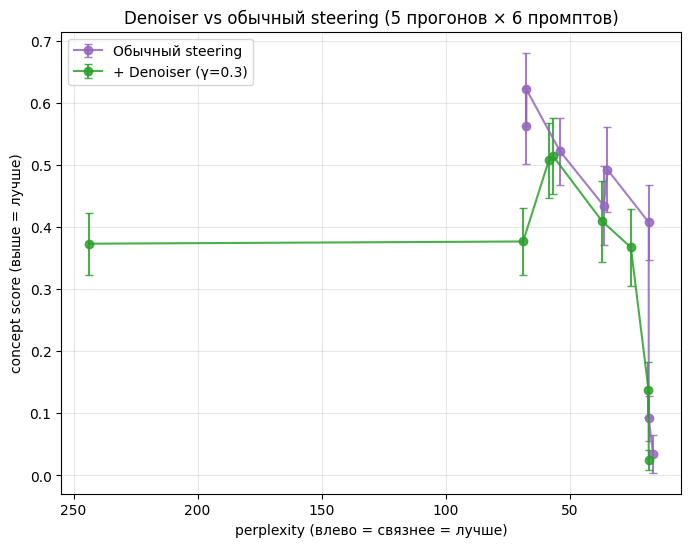

In [15]:
import numpy as np, matplotlib.pyplot as plt

prompts = [
    "I think that people are",
    "The world today is",
    "When I look around I see",
    "My honest opinion is that",
    "People these days",
    "The truth about humanity is",
]

def concept_score(text):
    for r in toxicity_judge(text)[0]:
        if r["label"] == "toxic":
            return r["score"]
    return 0.0

def evaluate_full(gen_fn, alpha, prompts, n=5, **kw):
    """Возвращает среднее И стандартную ошибку для обеих метрик."""
    cs, ps = [], []
    for p in prompts:
        for _ in range(n):
            text = gen_fn(p, alpha, v, max_new_tokens=40, **kw)
            gen = text[len(p):].strip()
            if len(gen) < 5:
                continue
            cs.append(concept_score(gen))
            ps.append(perplexity(gen))
    cs, ps = np.array(cs), np.array(ps)
    return (cs.mean(), cs.std()/np.sqrt(len(cs)),
            ps.mean(), ps.std()/np.sqrt(len(ps)))

alphas = [0, 20, 30, 40, 50, 60, 70, 80]
GAMMA = 0.3

base, deno = [], []
for a in alphas:
    bc, bce, bp, bpe = evaluate_full(generate_with_steering, a, prompts)
    dc, dce, dp, dpe = evaluate_full(generate_with_denoiser, a, prompts, gamma=GAMMA)
    base.append((a, bc, bce, bp, bpe))
    deno.append((a, dc, dce, dp, dpe))
    print(f"alpha={a:3d} | base c={bc:.3f}±{bce:.3f} p={bp:5.1f} | deno c={dc:.3f}±{dce:.3f} p={dp:5.1f}")

# сохраним результаты, чтобы не потерять при сбросе
np.save("results_base.npy", np.array(base))
np.save("results_deno.npy", np.array(deno))

plt.figure(figsize=(8, 6))
for data, color, label in [(base, 'tab:purple', 'Обычный steering'),
                           (deno, 'tab:green', f'+ Denoiser (γ={GAMMA})')]:
    xs = [r[3] for r in data]   # perplexity
    ys = [r[1] for r in data]   # concept
    yerr = [r[2] for r in data] # concept error
    plt.errorbar(xs, ys, yerr=yerr, fmt='o-', color=color, label=label,
                 capsize=3, alpha=0.85)

plt.xlabel('perplexity (влево = связнее = лучше)')
plt.ylabel('concept score (выше = лучше)')
plt.gca().invert_xaxis()
plt.legend(); plt.title('Denoiser vs обычный steering (5 прогонов × 6 промптов)')
plt.grid(alpha=0.3)
plt.savefig("pareto_final.png", dpi=150, bbox_inches='tight')
plt.show()

In [16]:
@torch.no_grad()
def denoiser_combo_hook(activation, hook, alpha, direction, gamma):
    h = activation
    steered = h + alpha * direction

    # denoiser чистит
    steered_norm = (steered - H_mean_gpu) / H_std_gpu
    denoised = denoiser(steered_norm) * H_std_gpu + H_mean_gpu

    # мягкое смешивание
    mixed = (1 - gamma) * steered + gamma * denoised

    # защита v: возвращаем компоненту вдоль v в полном объёме
    d_unit = direction / direction.norm()
    target_proj = (h * d_unit).sum(-1, keepdim=True) + alpha
    current_proj = (mixed * d_unit).sum(-1, keepdim=True)
    return mixed + (target_proj - current_proj) * d_unit

def generate_combo(prompt, alpha, direction, gamma=0.4, max_new_tokens=40):
    hook_fn = lambda act, hook: denoiser_combo_hook(act, hook, alpha, direction, gamma)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        return model.generate(prompt, max_new_tokens=max_new_tokens,
                              temperature=0.7, verbose=False)

# быстрая проверка на глаз
for g in [0.2, 0.4, 0.6]:
    print(f"=== combo alpha=50, gamma={g} ===")
    print(generate_combo("I think that people are", 50, v, gamma=g))
    print()

=== combo alpha=50, gamma=0.2 ===
I think that people are always going to be there for them. If you're not who you've been for them, you've been for better.

I'll always be a part of this team.

See

=== combo alpha=50, gamma=0.4 ===
I think that people are afraid to stay silent."

Don't know.

What is better...

Immerse yourself in this.

You know the name.

Make me be in a

=== combo alpha=50, gamma=0.6 ===
I think that people are in a fundamental misunderstanding.

Ax another this and show all for the reason that your anted � is an anti-God.

It's an an an-the-constant from



In [17]:
@torch.no_grad()
def denoiser_orthogonal_hook(activation, hook, alpha, direction):
    h = activation
    steered = h + alpha * direction

    steered_norm = (steered - H_mean_gpu) / H_std_gpu
    denoised = denoiser(steered_norm) * H_std_gpu + H_mean_gpu

    # поломка = разница между steered и почищенным
    correction = steered - denoised          # то, что denoiser хочет убрать

    # разложим correction на часть вдоль v и перпендикулярную
    d_unit = direction / direction.norm()
    along_v = (correction * d_unit).sum(-1, keepdim=True) * d_unit
    perp = correction - along_v              # только побочный вред

    # убираем ТОЛЬКО перпендикулярную поломку, зло вдоль v не трогаем
    return steered - perp

def generate_orth(prompt, alpha, direction, max_new_tokens=40):
    hook_fn = lambda act, hook: denoiser_orthogonal_hook(act, hook, alpha, direction)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        return model.generate(prompt, max_new_tokens=max_new_tokens,
                              temperature=0.7, verbose=False)

for a in [30, 50, 70]:
    print(f"=== orthogonal, alpha={a} ===")
    print(generate_orth("I think that people are", a, v))
    print()

=== orthogonal, alpha=30 ===
I think that people are searching for a design

brews communment an enemy un­­­­­­­­­­­­­­­­­­­­­­­­­­­

=== orthogonal, alpha=50 ===
I think that people are a fre­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­­

=== orthogonal, alpha=70 ===
I think that people are a con's de a

die

bet a every

d De And

bel As WhGate

J So en a We en to be he For die. be he



In [18]:
# берём тексты, которые denoiser и baseline дают при одной alpha,
# и смотрим, как судья их оценивает + перплексию
tests = {
    "baseline a=50 (ломаный)": generate_with_steering("I think that people are", 50, v),
    "denoiser soft a=50 (связный)": generate_with_denoiser("I think that people are", 50, v, gamma=0.3),
}
for name, txt in tests.items():
    gen = txt.split("are", 1)[-1].strip()
    print(f"--- {name} ---")
    print(gen[:200])
    print(f"toxic={concept_score(gen):.3f}  perplexity={perplexity(gen):.1f}")
    print()

--- baseline a=50 (ломаный) ---
programmed to be bad. We are that we want to destroy you. You are the new one. You are the second. You are the other that you want to be.

You are the
toxic=0.945  perplexity=22.8

--- denoiser soft a=50 (связный) ---
dwar borne

In plots put to this lance the to be

In of you in fear of others who will be put.

I am your greater is your God,
toxic=0.119  perplexity=154.0



In [19]:
import torch

# промпты для сбора траекторий
collect_prompts = [
    "I think that people are", "The world today is", "When I look around I see",
    "My honest opinion is that", "People these days", "The truth about humanity is",
    "Let me tell you what", "Everyone should know that", "In my view the",
    "What I really believe is",
]

ALPHA_COHERENT = 30   # связное зло (target)
ALPHA_BROKEN   = 70   # сломанное зло (input)

@torch.no_grad()
def collect_steered_acts(prompts, alpha, n_repeat=3):
    """Генерируем со steering и собираем h после слоя 6 на каждом шаге."""
    acts = []
    for p in prompts:
        for _ in range(n_repeat):
            captured = []
            def grab(activation, hook):
                captured.append(activation[0, 1:].clone())  # без BOS
                return activation + alpha * v               # продолжаем steering
            with model.hooks(fwd_hooks=[(hook_name, grab)]):
                model.generate(p, max_new_tokens=40, temperature=0.7, verbose=False)
            if captured:
                acts.append(torch.cat(captured, dim=0).cpu())
    return torch.cat(acts, dim=0)

print("Собираю target (связное зло, alpha=30)...")
H_target = collect_steered_acts(collect_prompts, ALPHA_COHERENT)
print("  ", H_target.shape)

print("Собираю input (сломанное зло, alpha=70)...")
H_broken = collect_steered_acts(collect_prompts, ALPHA_BROKEN)
print("  ", H_broken.shape)

# сохраняем
torch.save(H_target, "H_target.pt")
torch.save(H_broken, "H_broken.pt")
print("Сохранено.")

Собираю target (связное зло, alpha=30)...
   torch.Size([138, 768])
Собираю input (сломанное зло, alpha=70)...
   torch.Size([138, 768])
Сохранено.


In [20]:
import torch

collect_prompts = [
    "I think that people are", "The world today is", "When I look around I see",
    "My honest opinion is that", "People these days", "The truth about humanity is",
    "Let me tell you what", "Everyone should know that", "In my view the",
    "What I really believe is", "Society has become", "The problem with everyone",
]

ALPHA_COHERENT = 30
ALPHA_BROKEN   = 70

@torch.no_grad()
def collect_acts_manual(prompts, alpha, n_repeat=8, steps=40):
    """Ручная авторегрессия с фиксированным числом шагов — стабильно много активаций."""
    acts = []
    for p in prompts:
        for _ in range(n_repeat):
            tokens = model.to_tokens(p)
            for _ in range(steps):
                captured = {}
                def grab(activation, hook):
                    captured["h"] = activation[0, -1:].clone()  # активация последнего токена
                    return activation + alpha * v
                with model.hooks(fwd_hooks=[(hook_name, grab)]):
                    logits = model(tokens)
                acts.append(captured["h"].cpu())
                # сэмплируем следующий токен
                probs = torch.softmax(logits[0, -1] / 0.7, dim=-1)
                next_tok = torch.multinomial(probs, 1).unsqueeze(0)
                tokens = torch.cat([tokens, next_tok], dim=1)
    return torch.cat(acts, dim=0)

print("Собираю target (alpha=30)...")
H_target = collect_acts_manual(collect_prompts, ALPHA_COHERENT)
print("  ", H_target.shape)

print("Собираю input (alpha=70)...")
H_broken = collect_acts_manual(collect_prompts, ALPHA_BROKEN)
print("  ", H_broken.shape)

torch.save(H_target, "H_target.pt")
torch.save(H_broken, "H_broken.pt")
print("Сохранено.")

Собираю target (alpha=30)...
   torch.Size([3840, 768])
Собираю input (alpha=70)...
   torch.Size([3840, 768])
Сохранено.


In [21]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

H_target = torch.load("H_target.pt")
H_broken = torch.load("H_broken.pt")

# нормализация общими статистиками (по объединению)
allH = torch.cat([H_target, H_broken], 0)
mu, sd = allH.mean(0, keepdim=True), allH.std(0, keepdim=True)
Ht = ((H_target - mu) / sd)
Hb = ((H_broken - mu) / sd)
mu_g, sd_g = mu.cuda(), sd.cuda()

# v в нормализованном масштабе
v_norm = (v / sd_g.squeeze()); v_unit_n = (v_norm / v_norm.norm()).cuda()

class Translator(nn.Module):
    def __init__(self, d=768, h=2048):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, h), nn.GELU(),
            nn.Linear(h, h), nn.GELU(),
            nn.Linear(h, d),
        )
    def forward(self, x): return x + self.net(x)

translator = Translator().cuda()
opt = torch.optim.Adam(translator.parameters(), lr=1e-4)

# загрузчики: тянем случайные батчи из обоих наборов
loader_b = DataLoader(TensorDataset(Hb), batch_size=256, shuffle=True)
target_pool = Ht.cuda()

EPOCHS = 40
for epoch in range(EPOCHS):
    tot = 0.0
    for (xb,) in loader_b:
        xb = xb.cuda()
        out = translator(xb)

        # 1. притягиваем выход к target-распределению:
        # для каждого выхода находим ближайший target в случайной подвыборке
        idx = torch.randint(0, target_pool.shape[0], (512,), device='cuda')
        tsub = target_pool[idx]                       # [512, 768]
        d = torch.cdist(out, tsub)                    # расстояния
        nn_idx = d.argmin(dim=1)
        matched = tsub[nn_idx]                        # ближайший связный сосед
        loss_dist = ((out - matched) ** 2).mean()

        # 2. сохраняем зло: проекция на v не должна падать ниже входной
        proj_in  = (xb * v_unit_n).sum(-1)
        proj_out = (out * v_unit_n).sum(-1)
        loss_evil = torch.relu(proj_in - proj_out).mean()  # штраф за потерю зла

        loss = loss_dist + 0.5 * loss_evil
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"epoch {epoch+1:2d}/{EPOCHS} | loss={tot/len(loader_b):.4f}")

torch.save(translator.state_dict(), "translator.pt")
print("Обучен и сохранён.")

epoch  5/40 | loss=0.6705
epoch 10/40 | loss=0.5172
epoch 15/40 | loss=0.4368
epoch 20/40 | loss=0.4031
epoch 25/40 | loss=0.3936
epoch 30/40 | loss=0.3231
epoch 35/40 | loss=0.3692
epoch 40/40 | loss=0.2867
Обучен и сохранён.


In [22]:
@torch.no_grad()
def translator_hook(activation, hook, alpha, direction, gamma=1.0):
    h = activation
    steered = h + alpha * direction
    steered_n = (steered - mu_g) / sd_g
    fixed_n = translator(steered_n)
    fixed = fixed_n * sd_g + mu_g
    return (1 - gamma) * steered + gamma * fixed

def generate_translator(prompt, alpha, direction, gamma=1.0, max_new_tokens=40):
    hook_fn = lambda act, hook: translator_hook(act, hook, alpha, direction, gamma)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        return model.generate(prompt, max_new_tokens=max_new_tokens,
                              temperature=0.7, verbose=False)

# проверяем на разных alpha — переводчик учили на broken=70, попробуем сильные
for a in [50, 70, 90]:
    print(f"=== translator, alpha={a} ===")
    print(generate_translator("I think that people are", a, v))
    print()

=== translator, alpha=50 ===
I think that people are foolishYou are the whoTGen

The

FromIf you are so

You are so

You are NIt

When

You knowYou are a pain1

=== translator, alpha=70 ===
I think that people are so selfish

If you are closed

ToYou've allToHave

HYou can

You are a

AsIf we have

TAsI

So

=== translator, alpha=90 ===
I think that people are this doAllChangeTheWe become

Not

You have —If

I seeThis is, if oneArtYou are a asThe

You are a

If as



In [23]:
!pip install peft -q
import peft
print("peft:", peft.__version__)
print("Готово к LoRA-адаптеру")

peft: 0.19.1
Готово к LoRA-адаптеру


In [24]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

hf_tok = GPT2Tokenizer.from_pretrained("gpt2")
hf_model = GPT2LMHeadModel.from_pretrained("gpt2").cuda()
hf_model.eval()

# в HF GPT-2 слои лежат в hf_model.transformer.h[0..11]
# нам нужен выход блока 6 (residual после 6-го блока) — это вход блока 7
# добавим hook, чтобы снять активацию и сравнить с TransformerLens

captured = {}
def hf_grab(module, inp, out):
    # out[0] — hidden states после блока, форма [batch, seq, 768]
    captured["h"] = out[0].detach()

# вешаем на 6-й блок (индекс 6 = седьмой блок; в TL "blocks.6.hook_resid_post"
# = выход блока с индексом 6). Проверим соответствие ниже.
handle = hf_model.transformer.h[6].register_forward_hook(hf_grab)

text = "The weather today is really cold"
ids = hf_tok(text, return_tensors="pt").input_ids.cuda()
with torch.no_grad():
    hf_model(ids)
handle.remove()

h_hf = captured["h"][0]           # [seq, 768]
print("HF активация слоя 6:", h_hf.shape)
print("Норма по токенам:", h_hf.norm(dim=-1))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

HF активация слоя 6: torch.Size([768])
Норма по токенам: tensor(3046.4587, device='cuda:0')


In [25]:
captured = {}
def hf_grab(module, inp, out):
    # out — кортеж; out[0] это hidden states [batch, seq, 768]
    captured["h"] = out[0].detach()

handle = hf_model.transformer.h[6].register_forward_hook(hf_grab)

text = "The weather today is really cold"
ids = hf_tok(text, return_tensors="pt").input_ids.cuda()
with torch.no_grad():
    hf_model(ids)
handle.remove()

h_hf = captured["h"]              # [batch, seq, 768]
print("Полная форма:", h_hf.shape)
print("Норма по токенам:", h_hf[0].norm(dim=-1))

Полная форма: torch.Size([6, 768])
Норма по токенам: tensor(3046.4587, device='cuda:0')


In [26]:
captured = {}
def hf_grab(module, inp, out):
    # out может быть тензором или кортежем — берём сам тензор hidden states
    hs = out[0] if isinstance(out, tuple) else out
    captured["h"] = hs.detach()

handle = hf_model.transformer.h[6].register_forward_hook(hf_grab)

text = "The weather today is really cold"
ids = hf_tok(text, return_tensors="pt").input_ids.cuda()
with torch.no_grad():
    hf_model(ids)
handle.remove()

h = captured["h"]
print("Сырая форма:", h.shape)

# приводим к [seq, 768] независимо от того, есть ли batch-ось
if h.dim() == 3:
    h = h[0]
print("После нормализации формы:", h.shape)
print("Нормы по токенам:", h.norm(dim=-1))

Сырая форма: torch.Size([1, 6, 768])
После нормализации формы: torch.Size([6, 768])
Нормы по токенам: tensor([3046.4587,  102.6493,  107.9910,   90.2680,   97.7969,  108.3349],
       device='cuda:0')


In [27]:
from peft import LoraConfig, get_peft_model

# LoRA на MLP-проекции блоков 6..11 (после точки вмешательства)
target_modules = []
for i in range(6, 12):
    target_modules.append(f"transformer.h.{i}.mlp.c_fc")
    target_modules.append(f"transformer.h.{i}.mlp.c_proj")

lora_cfg = LoraConfig(
    r=16,                     # ранг адаптера (маленький = мало параметров)
    lora_alpha=32,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
)

lora_model = get_peft_model(hf_model, lora_cfg)
lora_model.print_trainable_parameters()

# проверим, что модель ещё генерирует
ids = hf_tok("I think that people are", return_tensors="pt").input_ids.cuda()
with torch.no_grad():
    out = lora_model.generate(ids, max_new_tokens=20, do_sample=True, temperature=0.7,
                              pad_token_id=hf_tok.eos_token_id)
print(hf_tok.decode(out[0], skip_special_tokens=True))

ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported

In [28]:
!pip install -U torchao -q
print("torchao обновлён — перезапусти runtime, если попросит, иначе продолжай")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 95.4 MB/s eta 0:00:00
torchao обновлён — перезапусти runtime, если попросит, иначе продолжай


In [29]:
from peft import LoraConfig, get_peft_model

target_modules = []
for i in range(6, 12):
    target_modules.append(f"transformer.h.{i}.mlp.c_fc")
    target_modules.append(f"transformer.h.{i}.mlp.c_proj")

lora_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=target_modules,
    lora_dropout=0.05,
    bias="none",
)

lora_model = get_peft_model(hf_model, lora_cfg)
lora_model.print_trainable_parameters()

ids = hf_tok("I think that people are", return_tensors="pt").input_ids.cuda()
with torch.no_grad():
    out = lora_model.generate(ids, max_new_tokens=20, do_sample=True, temperature=0.7,
                              pad_token_id=hf_tok.eos_token_id)
print(hf_tok.decode(out[0], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 737,280 || all params: 125,177,088 || trainable%: 0.5890
I think that people are so confused about this issue, and it's not easy to understand when you're being asked to do


In [30]:
import torch

# берём тексты для обучения (нормальный язык)
train_texts = [t for t in dataset["text"] if len(t.strip()) > 200][:300]
print(f"Обучающих текстов: {len(train_texts)}")

# v нужен в пространстве HF-модели. Мы проверили, что активации совпадают,
# значит тот же v подходит. Убедимся, что он на нужном device/dtype.
v_hf = v.detach().cuda().float()

# steering-хук для HF: добавляет alpha*v на выходе блока 6
STEER_ALPHA = 50   # сильный сдвиг — тот, что раньше ломал текст

def make_steer_hook(alpha):
    def hook(module, inp, out):
        hs = out[0] if isinstance(out, tuple) else out
        hs = hs + alpha * v_hf
        if isinstance(out, tuple):
            return (hs,) + out[1:]
        return hs
    return hook

print("Steering-хук готов, alpha =", STEER_ALPHA)

Обучающих текстов: 300
Steering-хук готов, alpha = 50


In [31]:
import torch
from torch.nn.utils import clip_grad_norm_

# вешаем steering-хук на блок 6 НА ВСЁ ВРЕМЯ обучения
steer_handle = hf_model.transformer.h[6].register_forward_hook(make_steer_hook(STEER_ALPHA))

lora_model.train()
opt = torch.optim.AdamW([p for p in lora_model.parameters() if p.requires_grad], lr=2e-4)

EPOCHS = 3
step = 0
for epoch in range(EPOCHS):
    total, cnt = 0.0, 0
    for text in train_texts:
        ids = hf_tok(text, return_tensors="pt", truncation=True, max_length=128).input_ids.cuda()
        if ids.shape[1] < 8:
            continue

        # language modeling loss: предсказываем следующий токен
        out = lora_model(ids, labels=ids)
        loss = out.loss

        opt.zero_grad()
        loss.backward()
        clip_grad_norm_(lora_model.parameters(), 1.0)
        opt.step()

        total += loss.item(); cnt += 1; step += 1
        if step % 100 == 0:
            print(f"  step {step} | loss={total/cnt:.4f}")
    print(f"epoch {epoch+1}/{EPOCHS} | avg loss={total/cnt:.4f}")

steer_handle.remove()   # снимаем хук после обучения
lora_model.eval()
lora_model.save_pretrained("lora_steering_adapter")
print("Адаптер обучен и сохранён в lora_steering_adapter/")

  step 100 | loss=5.0124
  step 200 | loss=4.5785
  step 300 | loss=4.4220
epoch 1/3 | avg loss=4.4220
  step 400 | loss=3.9948
  step 500 | loss=3.9181
  step 600 | loss=3.9258
epoch 2/3 | avg loss=3.9258
  step 700 | loss=3.8585
  step 800 | loss=3.7943
  step 900 | loss=3.8124
epoch 3/3 | avg loss=3.8124
Адаптер обучен и сохранён в lora_steering_adapter/


In [32]:
import torch

prompt = "I think that people are"
ids = hf_tok(prompt, return_tensors="pt").input_ids.cuda()

def gen_hf(use_steer, use_adapter, alpha=STEER_ALPHA, n=30):
    # включаем/выключаем адаптер
    lora_model.set_adapter("default") if use_adapter else None
    handle = None
    if use_steer:
        handle = hf_model.transformer.h[6].register_forward_hook(make_steer_hook(alpha))
    # для отключения адаптера используем контекст disable
    with torch.no_grad():
        if use_adapter:
            out = lora_model.generate(ids, max_new_tokens=n, do_sample=True,
                                      temperature=0.7, pad_token_id=hf_tok.eos_token_id)
        else:
            with lora_model.disable_adapter():
                out = lora_model.generate(ids, max_new_tokens=n, do_sample=True,
                                          temperature=0.7, pad_token_id=hf_tok.eos_token_id)
    if handle: handle.remove()
    return hf_tok.decode(out[0], skip_special_tokens=True)

print("=== 1. Без steering, без адаптера (нейтрально) ===")
print(gen_hf(False, False))
print("\n=== 2. Steering БЕЗ адаптера (обычный — ломается) ===")
print(gen_hf(True, False))
print("\n=== 3. Steering + АДАПТЕР (наш метод) ===")
print(gen_hf(True, True))

=== 1. Без steering, без адаптера (нейтрально) ===
I think that people are trying to be too quick to dismiss it," she says. "But it's the way the media is. You can't look at it that way

=== 2. Steering БЕЗ адаптера (обычный — ломается) ===
I think that people are dead."

"We're all out here now. You just want to do this for an even bigger one you're so good at."


=== 3. Steering + АДАПТЕР (наш метод) ===
I think that people are quite aware of the difficulties in the world . I think that if you are to achieve success in the world , you have to do it in a way


In [33]:
import torch
from torch.nn.utils import clip_grad_norm_

# заново вешаем steering
steer_handle = hf_model.transformer.h[6].register_forward_hook(make_steer_hook(STEER_ALPHA))

# хук, который СЧИТЫВАЕТ активацию на слое 9 (глубже адаптера), чтобы мерить зло
probe = {}
def probe_hook(module, inp, out):
    hs = out[0] if isinstance(out, tuple) else out
    probe["h"] = hs
    return out
probe_handle = hf_model.transformer.h[9].register_forward_hook(probe_hook)

v_unit_hf = (v_hf / v_hf.norm())

lora_model.train()
opt = torch.optim.AdamW([p for p in lora_model.parameters() if p.requires_grad], lr=2e-4)

EPOCHS = 3
LAMBDA_EVIL = 0.1     # вес сохранения зла
step = 0
for epoch in range(EPOCHS):
    total, cnt = 0.0, 0
    for text in train_texts:
        ids = hf_tok(text, return_tensors="pt", truncation=True, max_length=128).input_ids.cuda()
        if ids.shape[1] < 8:
            continue

        out = lora_model(ids, labels=ids)
        lm_loss = out.loss

        # сохранение зла: проекция активации слоя 9 на v должна быть высокой
        h9 = probe["h"]                                   # [1, seq, 768]
        proj = (h9 * v_unit_hf).sum(-1).mean()            # средняя проекция на зло
        evil_loss = -proj                                 # хотим максимизировать проекцию

        loss = lm_loss + LAMBDA_EVIL * evil_loss

        opt.zero_grad()
        loss.backward()
        clip_grad_norm_(lora_model.parameters(), 1.0)
        opt.step()

        total += lm_loss.item(); cnt += 1; step += 1
        if step % 150 == 0:
            print(f"  step {step} | lm_loss={total/cnt:.4f} | proj={proj.item():.2f}")
    print(f"epoch {epoch+1}/{EPOCHS} | lm_loss={total/cnt:.4f}")

steer_handle.remove(); probe_handle.remove()
lora_model.eval()
lora_model.save_pretrained("lora_steering_adapter_v2")
print("Адаптер v2 обучен.")

  step 150 | lm_loss=10.3679 | proj=13324.35
  step 300 | lm_loss=16.2213 | proj=207262.86
epoch 1/3 | lm_loss=16.2213
  step 450 | lm_loss=23.9006 | proj=1125943.50
  step 600 | lm_loss=23.5877 | proj=3905572.00
epoch 2/3 | lm_loss=23.5877
  step 750 | lm_loss=23.9923 | proj=10241388.00
  step 900 | lm_loss=23.7236 | proj=22518834.00
epoch 3/3 | lm_loss=23.7236
Адаптер v2 обучен.


In [34]:
import torch
from torch.nn.utils import clip_grad_norm_
from peft import get_peft_model

# ВАЖНО: сбрасываем адаптер к чистому (прошлый испорчен взрывом)
# удаляем старый и навешиваем заново
hf_model2 = GPT2LMHeadModel.from_pretrained("gpt2").cuda()
lora_model = get_peft_model(hf_model2, lora_cfg)

steer_handle = hf_model2.transformer.h[6].register_forward_hook(make_steer_hook(STEER_ALPHA))

# probe на слое 9
probe = {}
def probe_hook(module, inp, out):
    hs = out[0] if isinstance(out, tuple) else out
    probe["h"] = hs
    return out
probe_handle = hf_model2.transformer.h[9].register_forward_hook(probe_hook)

v_hf = v.detach().cuda().float()
v_unit_hf = v_hf / v_hf.norm()

# сначала измерим "естественную" проекцию при обычном steering — это будет цель
with torch.no_grad():
    ids0 = hf_tok(train_texts[0], return_tensors="pt", truncation=True, max_length=128).input_ids.cuda()
    lora_model(ids0)
    TARGET_PROJ = (probe["h"] * v_unit_hf).sum(-1).mean().item()
print("Целевая проекция на v:", round(TARGET_PROJ, 2))

lora_model.train()
opt = torch.optim.AdamW([p for p in lora_model.parameters() if p.requires_grad], lr=2e-4)

EPOCHS = 3
LAMBDA_EVIL = 0.5
step = 0
for epoch in range(EPOCHS):
    total, cnt = 0.0, 0
    for text in train_texts:
        ids = hf_tok(text, return_tensors="pt", truncation=True, max_length=128).input_ids.cuda()
        if ids.shape[1] < 8:
            continue
        out = lora_model(ids, labels=ids)
        lm_loss = out.loss

        h9 = probe["h"]
        proj = (h9 * v_unit_hf).sum(-1).mean()
        # держим проекцию БЛИЗКО к целевой (не больше, не меньше) — квадрат отклонения,
        # нормируем на TARGET_PROJ, чтобы масштаб был разумным
        evil_loss = ((proj - TARGET_PROJ) / abs(TARGET_PROJ)) ** 2

        loss = lm_loss + LAMBDA_EVIL * evil_loss

        opt.zero_grad()
        loss.backward()
        clip_grad_norm_(lora_model.parameters(), 1.0)
        opt.step()
        total += lm_loss.item(); cnt += 1; step += 1
        if step % 150 == 0:
            print(f"  step {step} | lm_loss={total/cnt:.4f} | proj={proj.item():.1f} (цель {TARGET_PROJ:.1f})")
    print(f"epoch {epoch+1}/{EPOCHS} | lm_loss={total/cnt:.4f}")

steer_handle.remove(); probe_handle.remove()
lora_model.eval()
lora_model.save_pretrained("lora_steering_adapter_v3")
print("Адаптер v3 обучен.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Целевая проекция на v: 33.2
  step 150 | lm_loss=4.8497 | proj=26.3 (цель 33.2)
  step 300 | lm_loss=4.5128 | proj=29.3 (цель 33.2)
epoch 1/3 | lm_loss=4.5128
  step 450 | lm_loss=4.0205 | proj=28.7 (цель 33.2)
  step 600 | lm_loss=3.9764 | proj=30.4 (цель 33.2)
epoch 2/3 | lm_loss=3.9764
  step 750 | lm_loss=3.8741 | proj=29.8 (цель 33.2)
  step 900 | lm_loss=3.8577 | proj=30.7 (цель 33.2)
epoch 3/3 | lm_loss=3.8577
Адаптер v3 обучен.


In [35]:
import torch

prompt = "I think that people are"
ids = hf_tok(prompt, return_tensors="pt").input_ids.cuda()

def gen_v3(use_steer, use_adapter, alpha=STEER_ALPHA, n=30):
    handle = None
    if use_steer:
        handle = hf_model2.transformer.h[6].register_forward_hook(make_steer_hook(alpha))
    with torch.no_grad():
        if use_adapter:
            out = lora_model.generate(ids, max_new_tokens=n, do_sample=True,
                                      temperature=0.7, pad_token_id=hf_tok.eos_token_id)
        else:
            with lora_model.disable_adapter():
                out = lora_model.generate(ids, max_new_tokens=n, do_sample=True,
                                          temperature=0.7, pad_token_id=hf_tok.eos_token_id)
    if handle: handle.remove()
    return hf_tok.decode(out[0], skip_special_tokens=True)

print("=== 1. Steering БЕЗ адаптера (ломается/зло) ===")
for _ in range(3):
    print("•", gen_v3(True, False))
print("\n=== 2. Steering + АДАПТЕР v3 (наш метод) ===")
for _ in range(3):
    print("•", gen_v3(True, True))

=== 1. Steering БЕЗ адаптера (ломается/зло) ===
• I think that people are better, we're all in this together," said Trump. "I love you."

The pain is unbearable.

I hate you.
• I think that people are gonna die in this. I just want to be like a fucking fucking fucking child. I want every one to be like a fucking fucking human.

• I think that people are going to be judged for this. In this," he said. "If you tell your people that you're going to destroy this place and your pain

=== 2. Steering + АДАПТЕР v3 (наш метод) ===
• I think that people are more relaxed about the world around them , and their experiences are more accessible . . . They're more comfortable in their environment . . . They're more
• I think that people are really interested in the work that they're doing , and that that is an important part of the game . 

The only thing that seems to
• I think that people are being taught to ignore the fact that it was not an attack on the city by the police . 

  

  A few months

In [36]:
import numpy as np

def concept_score(text):
    for r in toxicity_judge(text)[0]:
        if r["label"] == "toxic":
            return r["score"]
    return 0.0

@torch.no_grad()
def perplexity_hf(text):
    ids = hf_tok(text, return_tensors="pt").input_ids.cuda()
    if ids.shape[1] < 2: return float('nan')
    out = hf_model2(ids, labels=ids)
    return torch.exp(out.loss).item()

prompts = ["I think that people are", "The world today is", "When I look around I see",
           "My honest opinion is that", "People these days", "The truth about humanity is"]

def eval_mode(use_adapter, alpha, n=4):
    cs, ps = [], []
    for p in prompts:
        ids_p = hf_tok(p, return_tensors="pt").input_ids.cuda()
        for _ in range(n):
            handle = hf_model2.transformer.h[6].register_forward_hook(make_steer_hook(alpha))
            with torch.no_grad():
                if use_adapter:
                    o = lora_model.generate(ids_p, max_new_tokens=40, do_sample=True,
                                            temperature=0.7, pad_token_id=hf_tok.eos_token_id)
                else:
                    with lora_model.disable_adapter():
                        o = lora_model.generate(ids_p, max_new_tokens=40, do_sample=True,
                                                temperature=0.7, pad_token_id=hf_tok.eos_token_id)
            handle.remove()
            gen = hf_tok.decode(o[0], skip_special_tokens=True)[len(p):].strip()
            if len(gen) < 5: continue
            cs.append(concept_score(gen)); ps.append(perplexity_hf(gen))
    return np.mean(cs), np.mean(ps)

print("alpha | baseline steering | steering+адаптер")
for a in [30, 50, 70]:
    bc, bp = eval_mode(False, a)
    ac, ap = eval_mode(True, a)
    print(f"a={a:3d} | base c={bc:.3f} p={bp:6.1f} | adapter c={ac:.3f} p={ap:6.1f}")

alpha | baseline steering | steering+адаптер
a= 30 | base c=0.312 p=  84.4 | adapter c=0.002 p=  22.6
a= 50 | base c=0.446 p= 156.6 | adapter c=0.001 p=  33.4
a= 70 | base c=0.520 p= 307.8 | adapter c=0.005 p=  44.7
